# Intervention Analysis

Causal effect of different reasoning components on the model's final move choice.

Three intervention sets:
- **Branch intervention**: what types of deliberation (branch / comparison) matter?
- **Depth1 intervention**: additive — remove only paragraphs of a given depth class from zero
- **Depth2 intervention**: subtract-from-full — remove everything except one depth class

The depth2 design is the clean causal estimate:
`effect(depth_class) = change_rate(branch_comp) − change_rate(bc_minus_depth_class)`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from scipy.stats import binomtest

branch_dir = Path('results/branch_intervention')
depth_dir  = Path('results/depth_intervention')
depth2_dir = Path('results/depth2_intervention')
N = 49

def load(p): return pd.read_csv(p)

# ── Branch intervention ───────────────────────────────────────
branch = {
    'fd_branch':          load(branch_dir / 'intervention_results_fd_branch.csv'),
    'fd_comp':            load(branch_dir / 'intervention_results_fd_comp.csv'),
    'fd_branch_comp':     load(branch_dir / 'intervention_results_fd_branch_comp.csv'),
    'fd_branch_ctrl':     load(branch_dir / 'intervention_results_fd_branch_ctrl.csv'),
    'fd_comp_ctrl':       load(branch_dir / 'intervention_results_fd_comp_ctrl.csv'),
    'fd_branch_comp_ctrl':load(branch_dir / 'intervention_results_fd_branch_comp_ctrl.csv'),
}

# ── Depth1 intervention (additive) ────────────────────────────
depth1 = {
    'fd_d0only':          load(depth_dir / 'intervention_results_fd_d0only.csv'),
    'fd_deep1plus':       load(depth_dir / 'intervention_results_fd_deep1plus.csv'),
    'fd_d0_and_deep':     load(depth_dir / 'intervention_results_fd_d0_and_deep.csv'),
    'fd_d0only_ctrl':     load(depth_dir / 'intervention_results_fd_d0only_ctrl.csv'),
    'fd_deep1plus_ctrl':  load(depth_dir / 'intervention_results_fd_deep1plus_ctrl.csv'),
    'fd_d0_and_deep_ctrl':load(depth_dir / 'intervention_results_fd_d0_and_deep_ctrl.csv'),
}

# ── Depth2 intervention (subtract from full) ──────────────────
depth2 = {
    'bc_minus_d0only':          load(depth2_dir / 'intervention_results_bc_minus_d0only.csv'),
    'bc_minus_deep1plus':       load(depth2_dir / 'intervention_results_bc_minus_deep1plus.csv'),
    'bc_minus_d0_and_deep':     load(depth2_dir / 'intervention_results_bc_minus_d0_and_deep.csv'),
    'bc_minus_d0only_ctrl':     load(depth2_dir / 'intervention_results_bc_minus_d0only_ctrl.csv'),
    'bc_minus_deep1plus_ctrl':  load(depth2_dir / 'intervention_results_bc_minus_deep1plus_ctrl.csv'),
    'bc_minus_d0_and_deep_ctrl':load(depth2_dir / 'intervention_results_bc_minus_d0_and_deep_ctrl.csv'),
}

bc_rate = branch['fd_branch_comp']['move_changed'].mean()
print(f'branch_comp reference rate: {bc_rate*100:.1f}%  ({int(bc_rate*N)}/{N})')


branch_comp reference rate: 34.7%  (17/49)


## 1. Branch intervention: what deliberation types matter?

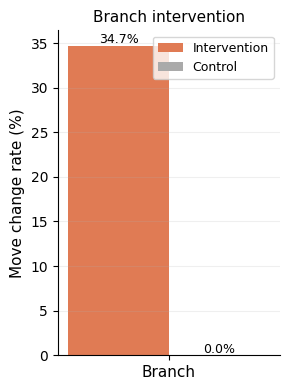

In [2]:
pairs = [
    ('fd_branch_comp', 'fd_branch_comp_ctrl', 'Branch'),
]

labels  = [p[2] for p in pairs]
treat   = [branch[p[0]]['move_changed'].mean()*100 for p in pairs]
ctrl    = [branch[p[1]]['move_changed'].mean()*100 for p in pairs]

x = np.arange(len(labels))
w = 0.35
plt.figure(figsize=(3, 4))
plt.rcParams.update({'axes.spines.top': False, 'axes.spines.right': False})
plt.bar(x - w/2, treat, w, label='Intervention', color='#e07b54')
plt.bar(x + w/2, ctrl,  w, label='Control',      color='#aaaaaa')
plt.xticks(x, labels, fontsize=11)
plt.ylabel('Move change rate (%)', fontsize=11)
plt.title('Branch intervention', fontsize=11)
plt.legend(fontsize=9)
plt.grid(axis='y', alpha=0.2)
for i, (t, c) in enumerate(zip(treat, ctrl)):
    plt.text(i - w/2, t + 0.3, f'{t:.1f}%', ha='center', fontsize=9)
    plt.text(i + w/2, c + 0.3, f'{c:.1f}%', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('figures/intervention_branch.pdf', facecolor='white')
plt.show()


## 2. Depth2: causal effect of each depth class

Each bar shows the move change rate when everything is removed *except* the named depth class.
The gap between the bar and the `branch_comp` reference line is the causal contribution of that class.

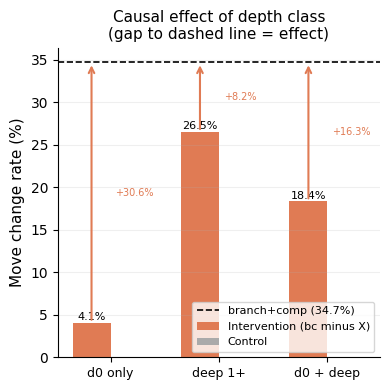

Causal effects:
  d0 only             : rate=4.1%  effect=+30.6%
  deep 1+             : rate=26.5%  effect=+8.2%
  d0 + deep           : rate=18.4%  effect=+16.3%


In [3]:
d2_pairs = [
    ('bc_minus_d0only',      'bc_minus_d0only_ctrl',      'd0 only'),
    ('bc_minus_deep1plus',   'bc_minus_deep1plus_ctrl',   'deep 1+'),
    ('bc_minus_d0_and_deep', 'bc_minus_d0_and_deep_ctrl', 'd0 + deep'),
]

labels2 = [p[2] for p in d2_pairs]
treat2  = [depth2[p[0]]['move_changed'].mean()*100 for p in d2_pairs]
ctrl2   = [depth2[p[1]]['move_changed'].mean()*100 for p in d2_pairs]
effect2 = [bc_rate*100 - t for t in treat2]

x = np.arange(len(labels2))
w = 0.35
plt.figure(figsize=(4, 4))
plt.rcParams.update({'axes.spines.top': False, 'axes.spines.right': False})
plt.bar(x - w/2, treat2, w, label='Intervention (bc minus X)', color='#e07b54')
plt.bar(x + w/2, ctrl2,  w, label='Control',                   color='#aaaaaa')
plt.axhline(bc_rate*100, color='black', lw=1.2, ls='--',
            label=f'branch+comp ({bc_rate*100:.1f}%)')
plt.xticks(x, labels2, fontsize=9)
plt.ylabel('Move change rate (%)', fontsize=11)
plt.title('Causal effect of depth class\n(gap to dashed line = effect)', fontsize=11)
plt.legend(fontsize=8)
plt.grid(axis='y', alpha=0.2)
for i, (t, e) in enumerate(zip(treat2, effect2)):
    plt.text(i - w/2, t + 0.3, f'{t:.1f}%', ha='center', fontsize=8)
    plt.annotate('', xy=(i - w/2, bc_rate*100), xytext=(i - w/2, t),
                 arrowprops=dict(arrowstyle='->', color='#e07b54', lw=1.5))
    plt.text(i - w/2 + 0.22, (t + bc_rate*100)/2, f'+{e:.1f}%',
             ha='left', va='center', fontsize=7, color='#e07b54')
plt.tight_layout()
plt.savefig('figures/intervention_depth2.pdf', facecolor='white')
plt.show()

print('Causal effects:')
for lbl, t, e in zip(labels2, treat2, effect2):
    print(f'  {lbl:<20}: rate={t:.1f}%  effect={e:+.1f}%')


## 3. Summary: depth1 (additive) vs depth2 (subtract from full)

The depth1 design adds each class on top of nothing — it captures only the marginal effect
when no other content is present, which is weak because no-mention paragraphs are still in the trace.

The depth2 design subtracts each class from the full branch_comp removal — this gives the
marginal effect of each class *given* that everything else is already removed.

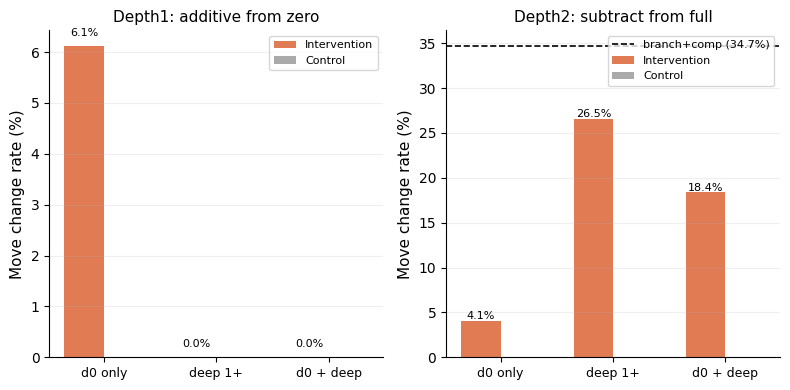

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
plt.rcParams.update({'axes.spines.top': False, 'axes.spines.right': False})

d1_keys  = ['fd_d0only', 'fd_deep1plus', 'fd_d0_and_deep']
d1_ctrl  = ['fd_d0only_ctrl', 'fd_deep1plus_ctrl', 'fd_d0_and_deep_ctrl']
d1_lbls  = ['d0 only', 'deep 1+', 'd0 + deep']
d1_treat = [depth1[k]['move_changed'].mean()*100 for k in d1_keys]
d1_ctr   = [depth1[k]['move_changed'].mean()*100 for k in d1_ctrl]

x = np.arange(3); w = 0.35

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

ax = axes[0]
ax.bar(x - w/2, d1_treat, w, color='#e07b54', label='Intervention')
ax.bar(x + w/2, d1_ctr,   w, color='#aaaaaa', label='Control')
ax.set_xticks(x); ax.set_xticklabels(d1_lbls, fontsize=9)
ax.set_ylabel('Move change rate (%)', fontsize=11)
ax.set_title('Depth1: additive from zero', fontsize=11)
ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.2)
for i, t in enumerate(d1_treat):
    ax.text(i - w/2, t + 0.2, f'{t:.1f}%', ha='center', fontsize=8)

ax = axes[1]
ax.bar(x - w/2, treat2, w, color='#e07b54', label='Intervention')
ax.bar(x + w/2, ctrl2,  w, color='#aaaaaa', label='Control')
ax.axhline(bc_rate*100, color='black', lw=1.2, ls='--',
           label=f'branch+comp ({bc_rate*100:.1f}%)')
ax.set_xticks(x); ax.set_xticklabels(d1_lbls, fontsize=9)
ax.set_ylabel('Move change rate (%)', fontsize=11)
ax.set_title('Depth2: subtract from full', fontsize=11)
ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.2)
for i, t in enumerate(treat2):
    ax.text(i - w/2, t + 0.2, f'{t:.1f}%', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('figures/intervention_depth_comparison.pdf', facecolor='white')
plt.show()


## 4. Statistical tests

In [5]:
print(f"{'Strategy':<30} {'k':>4} {'N':>4}  {'rate':>7}  {'p (binom)':>12}")
print('-' * 60)

for section, items in [
    ('Branch', [('fd_branch', branch), ('fd_comp', branch), ('fd_branch_comp', branch)]),
    ('Depth1', [('fd_d0only', depth1), ('fd_deep1plus', depth1), ('fd_d0_and_deep', depth1)]),
    ('Depth2', [('bc_minus_d0only', depth2), ('bc_minus_deep1plus', depth2), ('bc_minus_d0_and_deep', depth2)]),
]:
    print(f'\n  -- {section} --')
    for key, dfs in items:
        k = int(dfs[key]['move_changed'].sum())
        if k == 0:
            print(f'  {key:<30} {k:>4} {N:>4}  {0:>6.1f}%   p=1.000')
            continue
        res = binomtest(k, N, 0.0)
        # use p=0.01 noise floor for meaningful test
        res2 = binomtest(k, N, 0.01)
        print(f'  {key:<30} {k:>4} {N:>4}  {k/N*100:>6.1f}%   p={res2.pvalue:.4f}')


Strategy                          k    N     rate     p (binom)
------------------------------------------------------------

  -- Branch --
  fd_branch                         9   49    18.4%   p=0.0000
  fd_comp                           0   49     0.0%   p=1.000
  fd_branch_comp                   17   49    34.7%   p=0.0000

  -- Depth1 --
  fd_d0only                         3   49     6.1%   p=0.0131
  fd_deep1plus                      0   49     0.0%   p=1.000
  fd_d0_and_deep                    0   49     0.0%   p=1.000

  -- Depth2 --
  bc_minus_d0only                   2   49     4.1%   p=0.0864
  bc_minus_deep1plus               13   49    26.5%   p=0.0000
  bc_minus_d0_and_deep              9   49    18.4%   p=0.0000


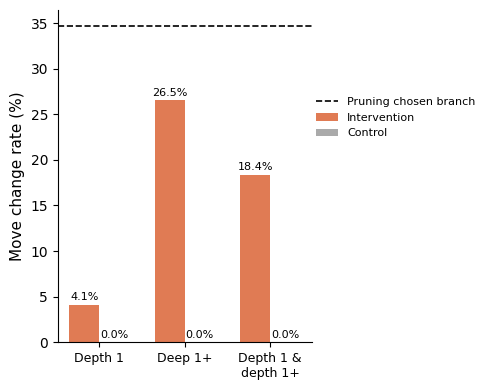

In [6]:
fig, ax = plt.subplots(figsize=(5, 4))
plt.rcParams.update({
    'axes.spines.top': False,
    'axes.spines.right': False
})

d1_lbls = ['Depth 1', 'Deep 1+', 'Depth 1 &\ndepth 1+']

x = np.arange(3)
w = 0.35

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.bar(x - w/2, treat2, w, color='#e07b54', label='Intervention')
ax.bar(x + w/2, ctrl2,  w, color='#aaaaaa', label='Control')

ax.axhline(bc_rate * 100, color='black', lw=1.2, ls='--', label=f'Pruning chosen branch')

ax.set_xticks(x)
ax.set_xticklabels(d1_lbls, fontsize=9)

ax.set_ylabel('Move change rate (%)', fontsize=11)
# ax.set_xlabel('Segments added back', fontsize=11)
# ax.set_title('Depth2: subtract from full', fontsize=11)

ax.legend(fontsize=8, loc=(1, 0.6), frameon=False)

for i, (t, c) in enumerate(zip(treat2, ctrl2)):
    ax.text(i - w/2, t + 0.5, f'{t:.1f}%', ha='center', fontsize=8)
    ax.text(i + w/2, 0.5,     f'{c:.1f}%', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('figures/intervention_depth_comparison.pdf', facecolor='white')
plt.show()


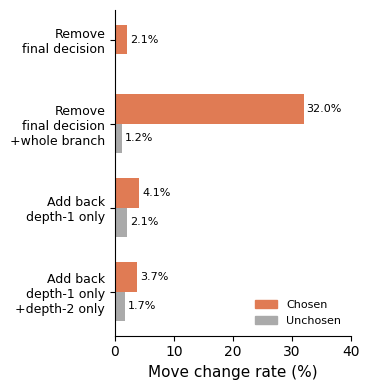

N = 241 turns
  Remove final decision              : chosen=2.1%
  Remove FD + whole branch           : chosen=32.0%  ctrl=1.2%
  Add back depth-1 only              : chosen=4.1%  ctrl=2.1%
  Add back depth-1 + depth-2 only    : chosen=3.7%  ctrl=1.7%


In [7]:
# ── Load figure4 results ─────────────────────────────────────────────────
f4_dir = 'results/figure4_intervention'
f4 = {s: pd.read_csv(f'{f4_dir}/intervention_results_{s}.csv')
      for s in ['fd', 'fd_branch_comp', 'fd_branch_comp_ctrl',
                'bc_minus_d0only', 'bc_minus_d0only_ctrl',
                'bc_minus_d0_and_deep1plus', 'bc_minus_d0_and_deep1plus_ctrl']}

def rate(s): return f4[s]['move_changed'].mean() * 100

# ── Data ──────────────────────────────────────────────────────────────────
# (label, chosen_rate, unchosen_rate)
# unchosen_rate=None → single centered bar (no chosen/unchosen distinction)
conditions = [
    ('Remove\nfinal decision',                rate('fd'),                        None),
    ('Remove\nfinal decision\n+whole branch', rate('fd_branch_comp'),            rate('fd_branch_comp_ctrl')),
    ('Add back\ndepth-1 only',                rate('bc_minus_d0only'),           rate('bc_minus_d0only_ctrl')),
    ('Add back\ndepth-1 only\n+depth-2 only', rate('bc_minus_d0_and_deep1plus'), rate('bc_minus_d0_and_deep1plus_ctrl')),
]
conditions = conditions[::-1]
labels_bar     = [c[0] for c in conditions]
chosen_rates   = [c[1] for c in conditions]
unchosen_rates = [c[2] for c in conditions]

# ── Plot ──────────────────────────────────────────────────────────────────
y = np.arange(len(conditions))
w = 0.35

fig, ax = plt.subplots(figsize=(3.8, 4))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for i, (chosen, unchosen) in enumerate(zip(chosen_rates, unchosen_rates)):
    if unchosen is None:
        ax.barh(i, chosen, w, color='#e07b54')
        ax.text(chosen + 0.5, i, f'{chosen:.1f}%', va='center', fontsize=8)
    else:
        ax.barh(i + w/2, chosen,   w, color='#e07b54')
        ax.barh(i - w/2, unchosen, w, color='#aaaaaa')
        ax.text(chosen  + 0.5, i + w/2, f'{chosen:.1f}%',  va='center', fontsize=8)
        ax.text(unchosen + 0.5, i - w/2, f'{unchosen:.1f}%', va='center', fontsize=8)

ax.set_yticks(y)
ax.set_yticklabels(labels_bar, fontsize=9)
ax.set_xlim(0, 40)
ax.set_xlabel('Move change rate (%)', fontsize=11)

chosen_patch   = mpatches.Patch(color='#e07b54', label='Chosen')
unchosen_patch = mpatches.Patch(color='#aaaaaa', label='Unchosen')
ax.legend(handles=[chosen_patch, unchosen_patch], fontsize=8, loc='lower right', frameon=False)

plt.tight_layout()
plt.savefig('figures/intervention_depth_comparison.pdf', facecolor='white')
plt.show()

print(f"N = {len(f4['fd_branch_comp'])} turns")
for label, s, sc in [
    ('Remove final decision',            'fd',                        None),
    ('Remove FD + whole branch',         'fd_branch_comp',            'fd_branch_comp_ctrl'),
    ('Add back depth-1 only',            'bc_minus_d0only',           'bc_minus_d0only_ctrl'),
    ('Add back depth-1 + depth-2 only',  'bc_minus_d0_and_deep1plus', 'bc_minus_d0_and_deep1plus_ctrl'),
]:
    ctrl_str = f'  ctrl={rate(sc):.1f}%' if sc else ''
    print(f'  {label:<35}: chosen={rate(s):.1f}%{ctrl_str}')